____
**Universidad Tecnológica Nacional, Buenos Aires**<br/>
**Ingeniería Industrial**<br/>
**Cátedra de Ciencia de Datos - Curso I5571 - Turno jueves noche**<br/>
**Clase_02:** EDA : Analisis Exploratorio de los Datos<br/>
**Elaborado por:** Nicolas Aguirre
____

# Librerias

In [2]:
#Importar paquetes de herramientas:
#Datos
import pandas as pd
import numpy as np
#Graficos 
import matplotlib.pyplot as plt
import seaborn as sns
#Otros 
import warnings
warnings.filterwarnings('ignore')

# Dataset

El dataset  que usaremos se encuentra en:
  
**https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data**

* Descargar e importarlo


* Verificar que se haya cargado bien el dataset


* Dimension del dataset

In [3]:
df = pd.read_csv('AB_NYC_2019.csv',index_col="id")

In [4]:
print(f'Shape: {np.shape(df)}')
df.head(3)

Shape: (48895, 15)


,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
id,,,,,,,,,,,,,,,
2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365


# Limpieza

* **Duplicados**


* **Cantidad** y **% de NaN** por columna


* Luego de quitarlos, devolver shape del df

In [5]:
df.drop_duplicates(inplace=True,keep='first')

In [6]:
cant_NaN = df.isnull().sum()
print(cant_NaN,'\r\n')

name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64 



In [7]:
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(6)

,Total,Percent
last_review,10052,0.205583
reviews_per_month,10052,0.205583
host_name,21,0.000429
name,16,0.000327
host_id,0,0.000000
neighbourhood_group,0,0.000000


In [8]:
#Limpiamos registros
df.dropna(how ='any', inplace = True)

In [9]:
# Verificamos como quedo el data-set
print(f'Nos quedamos con un df de {df.shape[0]} filas x{df.shape[1]} columnas')

Nos quedamos con un df de 38821 filas x15 columnas


# Practica!

1. Crear columna $\log($precio$)$. Grafico de la distribucion de precio y de $\log($precio$)$


2. En base al que mejor se ajuste, comparar los precios segun los distintos `neighbourhood_group` (boxplot)


3. Mediana, Limite inferior y superior del `neighbourhood_group` con mayor y menor precio.


4. Crear una nueva columa llamada `Brand`, con 7 categorias de precios. 
        
    `Bandas = [0, 50, 75, 100, 150, 200, 250]`


5. Boxplot de `Brand` vs $\log($Reviews$)$


6. Scatter plot de Longitud y Latitud donde se distinga `neighbourhood_group`


7. Scatter plot de Longitud y Latitud donde se distingan las brands


8. Cantidad de barrios


9. Comparacion de la cantidad de hospedajes para los 10 barrios mas populares (barras)


10. Cantidad de hospedajes para los 10 barrios mas populares, segregados por brands (`pivot_table`)


## Log de precio y dist. estimada

Crear columna $\log($precio$)$. Grafico de la distribucion de precio y de $\log($precio$)$


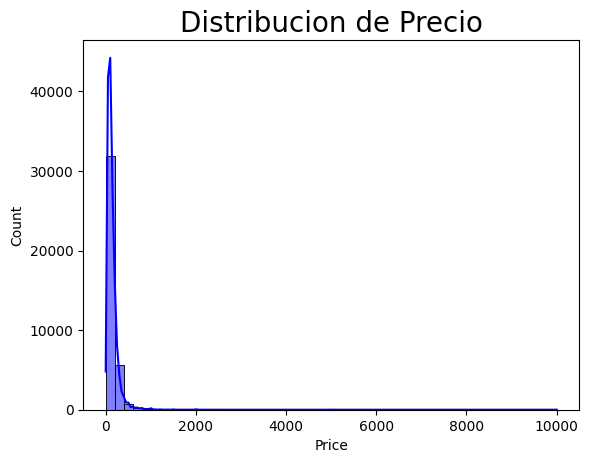

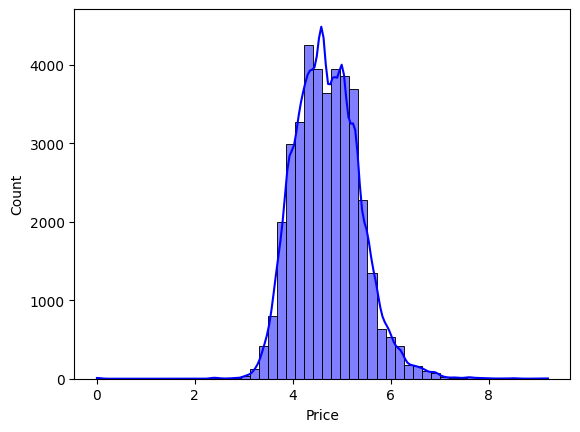

In [10]:
#Columna log precios
df['log_price'] = np.log(1+df['price'])

#Plot Precio
sns.histplot(df['price'],bins=50,color='b',kde=True,stat='count')
plt.xlabel("Price")
plt.title('Distribucion de Precio',size = 20)
plt.show()

#Plot Log-Precio
sns.histplot(np.log(1+df['price']),bins=50,color='b',kde=True,stat='count')
plt.xlabel("Price")
plt.show()

## Box plot `neighbourhood_group`

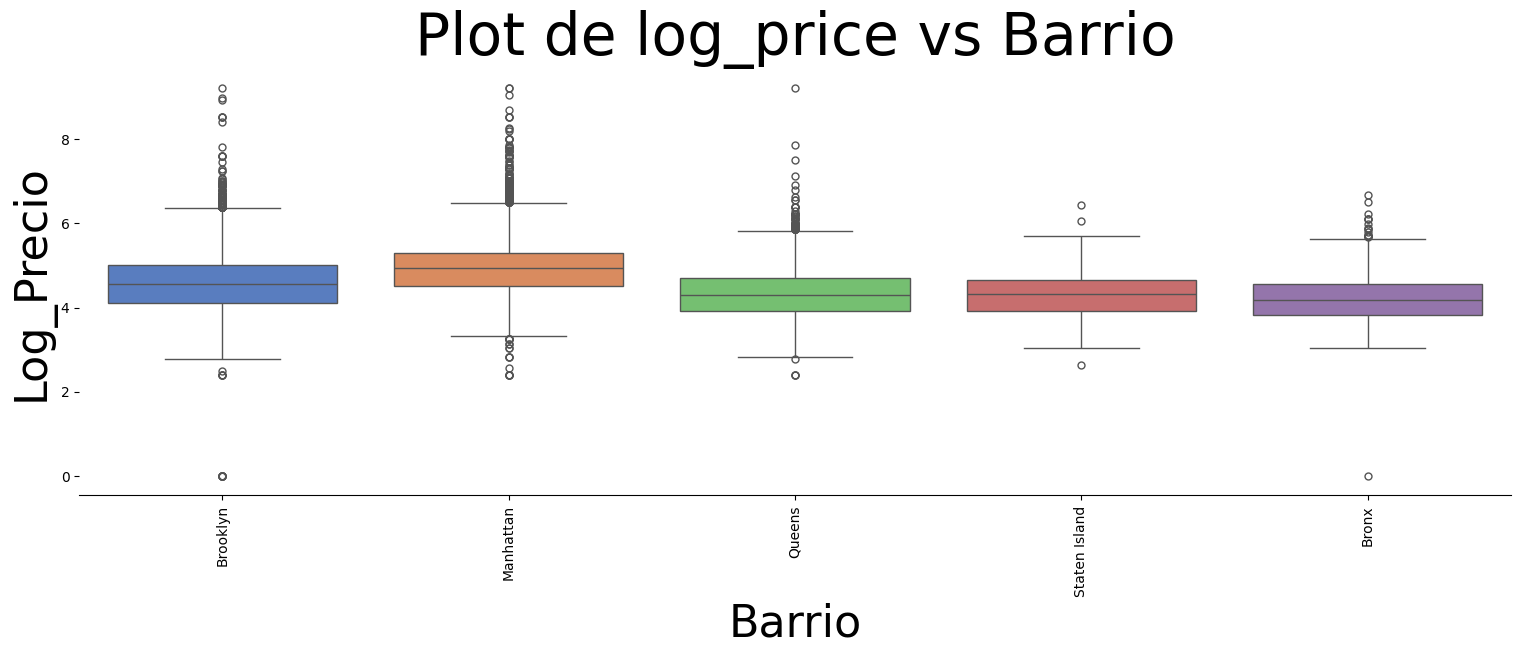

In [11]:
#En base al que mejor se ajuste, comparar los precios segun los distintos "neighbourhood_group" (boxplot)
g = sns.catplot(data=df,
                x='neighbourhood_group',y='log_price', 
                kind="box", height = 5 ,aspect=3,palette = "muted")
g.despine(left=True)
g.set_xticklabels(rotation=90)
plt.xlabel("Barrio",fontsize=32)
plt.ylabel("Log_Precio",fontsize=32)
plt.title('Plot de log_price vs Barrio',size = 42)
plt.show()

## Mediana, Lim. Inferior y Sup.

,Mediana,Lim. Inferior,Lim. Superior
Manhattan,4.94876,4.51086,6.486161


,Mediana,Lim. Inferior,Lim. Superior
Bronx,4.189655,3.828641,5.638355


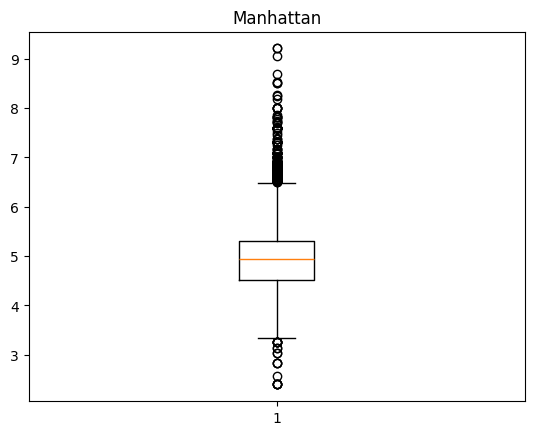

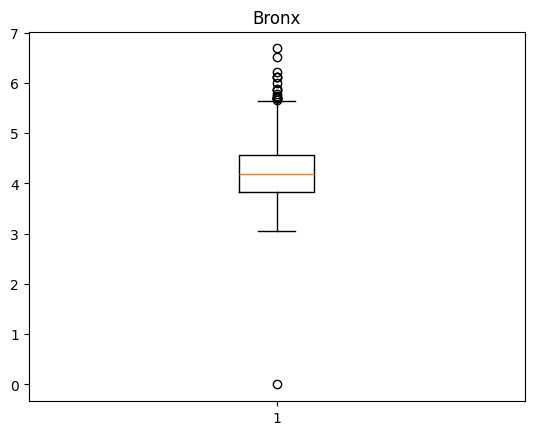

In [12]:
# Mediana, Limite inferior y superior del 'neighbourhood_group' con mayor y menor precio.

grup1 = 'Manhattan'
df_pivot = df[df['neighbourhood_group']==grup1]
plt.figure()
A = plt.boxplot(df_pivot['log_price'])
plt.title(grup1)
medians = [median.get_ydata() for median in A["medians"]]
#whiskers
whiskers = [whiskers.get_ydata() for whiskers in A["whiskers"]]
#print(f'Valores outliers:\r\n{outliers[0]}\r\n')
df2delete = pd.DataFrame({'Mediana': medians[0][0],
                            'Lim. Inferior': whiskers[0][0],
                            'Lim. Superior': whiskers[1][1]},index=[grup1])
display(df2delete)
grup2 = 'Bronx'
df_pivot= df[df['neighbourhood_group']==grup2]
plt.figure()
A = plt.boxplot(df_pivot['log_price'])
plt.title(grup2)
medians = [median.get_ydata() for median in A["medians"]]
#whiskers
whiskers = [whiskers.get_ydata() for whiskers in A["whiskers"]]
df2delete = pd.DataFrame({'Mediana': medians[0][0],
                            'Lim. Inferior': whiskers[0][0],
                            'Lim. Superior': whiskers[1][1]},index=[grup2])
display(df2delete)

#print(f'Valores outliers:\r\n{outliers[0]}\r\n')

## Brands

`
    Bandas = [0, 50, 75, 100, 150, 200, 250]
`

Podriamos hacerlo como la clase pasada ... pero veamos una manera usando **for loop** y **enumerate**. 

In [13]:
# df.loc[(df['price'] > 0) & (df['price'] <= 50), 'Banda'] = 1
# df.loc[(df['price'] > 50) & (df['price'] <= 75), 'Banda']   = 2
# df.loc[(df['price'] > 75) & (df['price'] <= 100), 'Banda']   = 3
# df.loc[(df['price'] > 100) & (df['price'] <= 150), 'Banda']   = 4
# df.loc[(df['price'] > 150) & (df['price'] <= 200), 'Banda']   = 5
# df.loc[(df['price'] > 200) & (df['price'] <= 250), 'Banda']   = 6
# df.loc[(df['price'] > 250), 'Banda']  = 7

In [14]:
#Definimos y creamos las bandas:
list_bandas = [0,50,75,100,150,200,250]

Usaremos un `for` loop con `enumerate`

In [15]:
# El enumerate simplemente agrega al iterador una variable que "enumera" las iteraciones.
for i, i_banda in enumerate(list_bandas,start=1):
    if i < len(list_bandas):
        banda_i = list_bandas[i-1]
        banda_f = list_bandas[i]
        print(f"Enumerate --> i= {i}, banda_i= {banda_i}, banda_f= {banda_f}")
        df.loc[(df['price'] > banda_i) & (df['price'] <= banda_f), 'Banda']   = i
    else:
        banda_f = i_banda
        print(f"Enumerate --> i= {i}, banda_f= {banda_f}")
        df.loc[(df['price'] > banda_f), 'Banda']  = i

Enumerate --> i= 1, banda_i= 0, banda_f= 50
Enumerate --> i= 2, banda_i= 50, banda_f= 75
Enumerate --> i= 3, banda_i= 75, banda_f= 100
Enumerate --> i= 4, banda_i= 100, banda_f= 150
Enumerate --> i= 5, banda_i= 150, banda_f= 200
Enumerate --> i= 6, banda_i= 200, banda_f= 250
Enumerate --> i= 7, banda_f= 250


Ejercicio rapido!
Dada la siguente dos lista
```python
numeros = [10,11,12,13]
letras = ['a','b','c','d']
```

prueben correr
```python
for i, n in enumerate(numeros):
    print(i, n)
```
y luego:

```python
for i (n,l) in enumerate(zip(numeros,letras)):
    print(i,n,l)
```

E interpreten los resultados

## Brand vs $\log($Reviews$)$

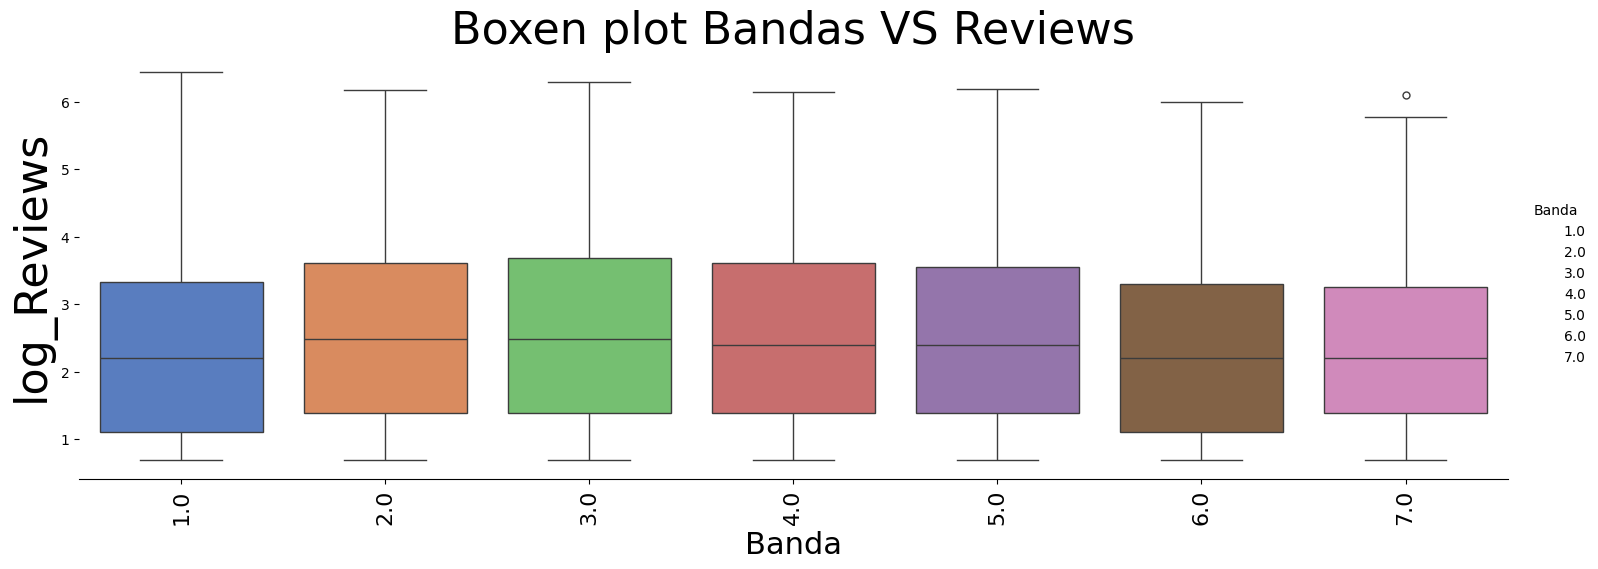

In [16]:
#Boxplot de "Bandas" vs log(Reviews)
df['log_review'] = np.log(1+df['number_of_reviews'])

g = sns.catplot(data=df,
                x="Banda",y='log_review', 
                kind="box", height = 5,aspect=3 ,palette = "muted")
g.despine(left=True)
g.set_xticklabels(size=16,rotation=90)
g = g.set_ylabels("log_Reviews",size=32)
g = g.set_xlabels("Banda",size=22)
plt.title('Boxen plot Bandas VS Reviews',size = 32)
plt.show()

## Scatter Plot: *neighbourhood_group*

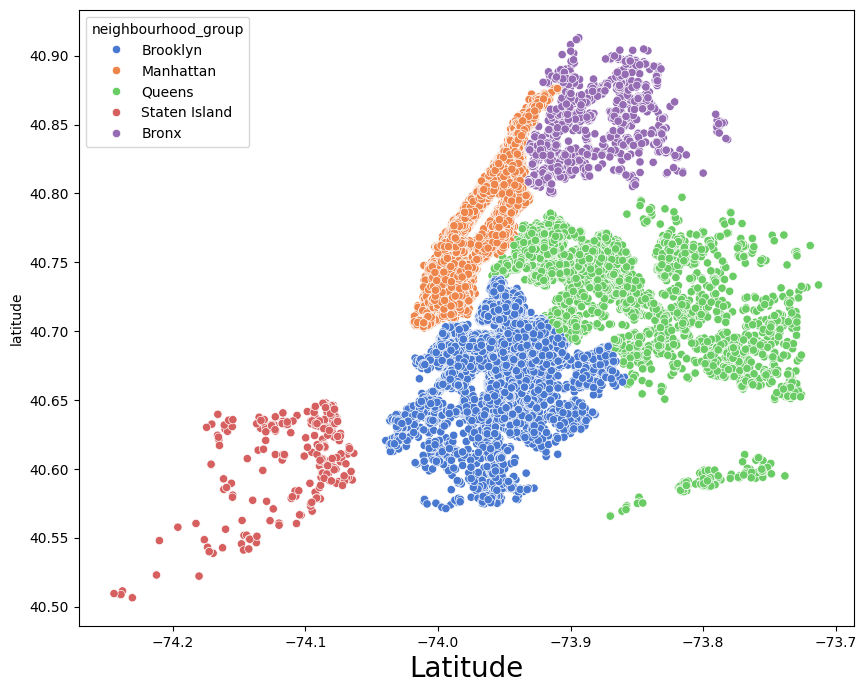

In [17]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=df.longitude,y=df.latitude,
                hue=df.neighbourhood_group,palette='muted')
plt.xlabel("Longitude",fontsize=20)
plt.xlabel("Latitude",fontsize=20)

plt.show()

## Scatter Plot: Brands

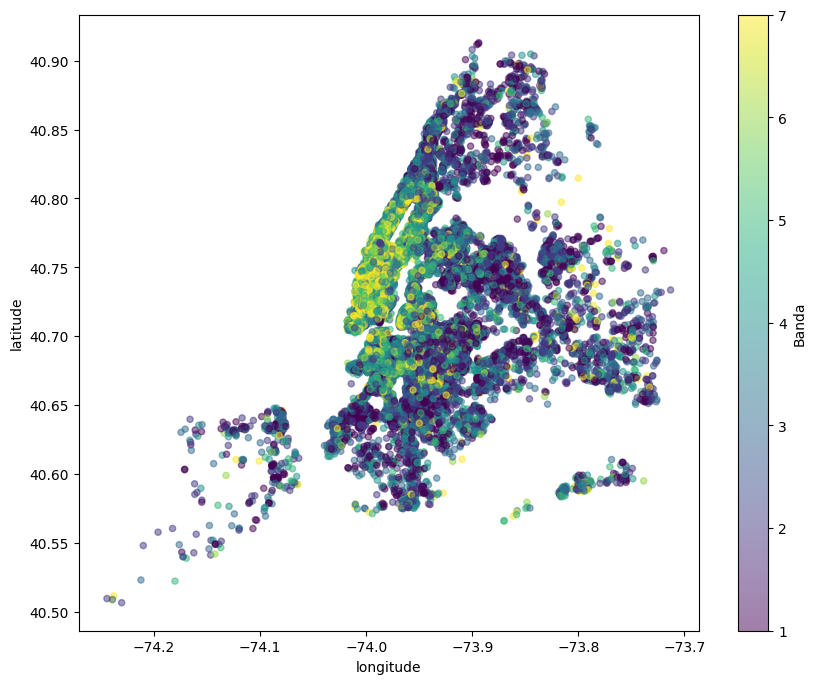

In [18]:
# Podemos aplicar tambien algunas funciones de plot sobre el dataframe usando pd.plot( )
df.plot(kind='scatter', x='longitude', y='latitude', c='Banda',
        cmap=plt.get_cmap(), colorbar=True, alpha=0.5, figsize=(10,8))
plt.show()

## Qty de barrios

In [19]:
q_barrios = len(df['neighbourhood'].unique())
print(f'En total hay {q_barrios} barrios\r\n')

En total hay 218 barrios



## Hospedajes para los 10 barrios mas populares

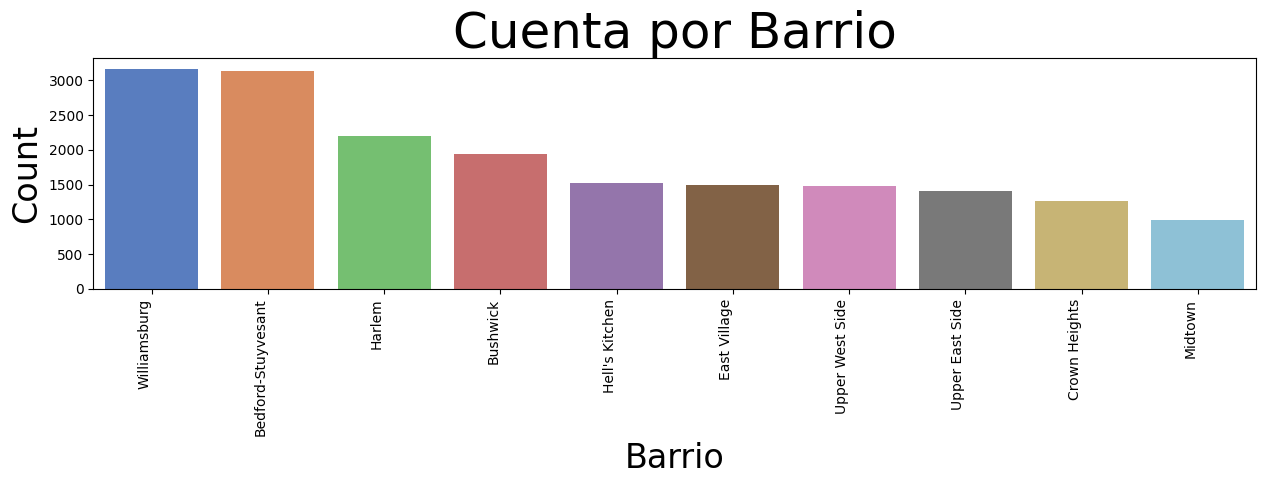

In [20]:
top_neighbourhood = df['neighbourhood'].value_counts().index[0:10]


plt.figure(figsize=(15,3))
g = sns.countplot(x='neighbourhood',data=df, palette = "muted",order=top_neighbourhood)
g.set_xticklabels(g.get_xticklabels(), rotation=90, ha="right")
plt.title('Cuenta por Barrio',size = 36)
plt.xlabel("Barrio",size = 24)
plt.ylabel("Count",size = 24)
plt.show()

## Cantidad de hospedajes para los 10 barrios mas populares, segregados por brands 

### Pivot Table

Veamos un poqueño tutorial de [**Pivot Tables**](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pivot_table.html)

In [21]:
#Generamos un datafame de ejemplo
df2delete = pd.DataFrame({"A": ["foo", "foo", "foo", "foo", "foo",
                         "bar", "bar", "bar", "bar"],
                   "B": ["one", "one", "one", "two", "two",
                         "one", "one", "two", "two"],
                   "C": ["small", "large", "large", "small",
                         "small", "large", "small", "small",
                         "large"],
                   "D": [1, 2, 2, 3, 3, 4, 5, 6, 7],
                   "E": [2, 4, 5, 5, 6, 6, 8, 9, 9]})
df2delete

,A,B,C,D,E
0,foo,one,small,1,2
1,foo,one,large,2,4
2,foo,one,large,2,5
3,foo,two,small,3,5
4,foo,two,small,3,6
5,bar,one,large,4,6
6,bar,one,small,5,8
7,bar,two,small,6,9
8,bar,two,large,7,9


In [22]:
# Como se utiliza ...
table = pd.pivot_table(df2delete, # Datos
                       values=['D'], # Valores que van a aparecer dentro de la tabla
                       index=['A', 'B'], # Los indices que ve a tener
                    columns=['C'], # La columna que va a tener
                       aggfunc=np.sum) # Que se aplicara a los valores
table

D      
C       large small
A   B              
bar one   4.0   5.0
    two   7.0   6.0
foo one   4.0   1.0
    two   NaN   6.0

In [23]:
table = pd.pivot_table(df2delete,
                       # Multiples valores
                       values=['D', 'E'],
                       index=['A'],
                       # Tambien por columna
                       columns=['C'],
                       # Y con multiples funciones para cada uno de los valores
                       aggfunc={'D': np.mean,
                                'E': ['min', max, np.mean]})
table

D               E                                  
     mean             max        mean             min      
C   large     small large small large     small large small
A                                                          
bar   5.5  5.500000     9     9   7.5  8.500000     6     8
foo   2.0  2.333333     5     6   4.5  4.333333     4     2

In [25]:
table = pd.pivot_table(
    # Datframe
    df[df['neighbourhood'].isin(top_neighbourhood)],
    # Filas
    index='neighbourhood',
    # Columnas
    columns = 'Banda',
    # Quiero ver los log_precios
    values='log_price' ,
    # si hay NaN, pongo un cero 
    fill_value=0,
    # Que funcion aplico?
    aggfunc = 'count')
table

Banda,1.0,2.0,3.0,4.0,5.0,6.0,7.0
neighbourhood,,,,,,,
Bedford-Stuyvesant,662,804,563,651,290,73,94
Bushwick,610,609,312,240,95,39,34
Crown Heights,238,288,268,261,102,41,67
East Village,15,112,283,421,316,152,190
Harlem,251,595,518,446,208,69,117
Hell's Kitchen,12,128,226,397,352,153,260
Midtown,4,30,87,236,191,120,318
Upper East Side,30,84,233,519,281,115,143
Upper West Side,45,147,262,384,306,123,215


# Consultas ?